# Split Federated Learning (SFL) — Server-Side Training
## Hospital Mortality Prediction · MIMIC-IV 3.1

---

### System Architecture

```
Client Side (private — data never leaves)    |   Server Side (this notebook)
---------------------------------------------|-----------------------------
Raw ICU Features  [B × 266]                  |
        ↓  ClientEncoder                      |
    Linear(266→64) → BN → ReLU               |
    Dropout(0.5)                              |
    Linear(64→32)  → BN → ReLU               |
Smashed Data      [B × 32]  ───────────────► |  ServerTopModel
                                             |  Linear(32→16) → BN → ReLU
                                             |  Dropout(0.3)  → Linear(16→1)
                                             |  loss = BCEWithLogitsLoss
Gradient          [B × 32]  ◄─────────────── |  smashed.grad
        ↓  activation.backward(grad)         |
    encoder_optimizer.step()                 |  server_optimizer.step()
```

### Privacy Guarantee
Raw patient records never leave the client. The server receives only
32-dimensional encoded activations — no identifiable clinical features.

### Training Protocol
| Phase | Rounds | Encoder | Server |
|-------|--------|---------|--------|
| Warm-up   | 1–10  | Frozen (eval mode) | Trained |
| Fine-tune | 11–50 | Trained (joint)    | Trained |

### Clients (non-IID split by ICU care unit)
| ID | Unit Type | Samples | Mortality Rate |
|----|-----------|---------|----------------|
| 0  | Medical   | 36,153  | 16.1%          |
| 1  | Surgical  | 23,484  | 11.5%          |
| 2  | Cardiac   | 32,744  |  6.9%          |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Verify core dependencies (all pre-installed on Colab GPU runtimes)
import importlib
for pkg in ['torch', 'sklearn', 'pandas', 'numpy', 'matplotlib']:
    mod = importlib.import_module(pkg if pkg != 'sklearn' else 'sklearn')
    ver = getattr(mod, '__version__', '?')
    print(f'  {pkg:<12} {ver}')

  torch        2.10.0+cu128
  sklearn      1.6.1
  pandas       2.2.2
  numpy        2.0.2
  matplotlib   3.10.0


In [3]:
import os
import copy
import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
)

print('Imports OK')

Imports OK


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_BASE  = '/content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1'
DATA_DIR    = f'{DRIVE_BASE}/data/processed'
MODELS_DIR  = f'{DRIVE_BASE}/models'
RESULTS_DIR = f'{DRIVE_BASE}/results/server'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Client registry ──────────────────────────────────────────────────────────
CLIENT_INFO = [
    {'id': 0, 'name': 'medical'},
    {'id': 1, 'name': 'surgical'},
    {'id': 2, 'name': 'cardiac'},
]
NUM_CLIENTS = len(CLIENT_INFO)

# Binary vasopressor columns — excluded from StandardScaler (match client training)
VASO_COLS = [
    'vaso_dopamine', 'vaso_epinephrine', 'vaso_norepinephrine',
    'vaso_phenylephrine', 'vaso_vasopressin',
]

# ── Architecture ─────────────────────────────────────────────────────────────
INPUT_DIM      = 266   # raw feature dimension per client
ENCODER_HIDDEN = 64    # encoder first hidden layer
ACTIVATION_DIM = 32    # encoder output = server input (smashed data)
SERVER_HIDDEN  = 16    # server top model hidden layer

# ── Training hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE          = 64
NUM_ROUNDS          = 50
WARMUP_ROUNDS       = 10    # encoder frozen for rounds 0..WARMUP_ROUNDS-1
LR_SERVER           = 1e-4
LR_ENCODER          = 1e-4  # encoder fine-tuning LR (matches local training)
WEIGHT_DECAY        = 1e-3
SCHEDULER_PATIENCE  = 3
SCHEDULER_FACTOR    = 0.5
EARLY_STOP_PATIENCE = 8
MAX_POS_WEIGHT      = 5.0   # imbalance cap (consistent with client training)
SEED                = 42

print('Configuration loaded.')
print(f'  Results will be saved to: {RESULTS_DIR}')

Configuration loaded.
  Results will be saved to: /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server


In [5]:
import random

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


## Model Definitions

In [6]:
class ClientEncoder(nn.Module):
    """
    Client-side encoder — architecture must exactly match local pre-training
    so that saved state_dicts load without key mismatches.

    Input : (B, 266)  raw (scaled + clipped) ICU features
    Output: (B,  32)  smashed-data activation vector
    """
    def __init__(self, input_dim: int = INPUT_DIM, hidden_dim: int = ENCODER_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ServerTopModel(nn.Module):
    """
    Server-side classification head shared across all clients.
    Receives 32-dim smashed data; outputs a single mortality logit.

    Input : (B, 32)  smashed-data activation
    Output: (B,  1)  unnormalised logit (sigmoid → mortality probability)
    """
    def __init__(self, input_dim: int = ACTIVATION_DIM, hidden_dim: int = SERVER_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Sanity-check parameter counts
_enc_test = ClientEncoder()
_srv_test = ServerTopModel()
print(f'ClientEncoder params : {sum(p.numel() for p in _enc_test.parameters()):,}')
print(f'ServerTopModel params: {sum(p.numel() for p in _srv_test.parameters()):,}')
del _enc_test, _srv_test

ClientEncoder params : 19,360
ServerTopModel params: 577


## Data Loading & Preprocessing

In [7]:
def load_and_preprocess_client(
    client_id: int,
    client_name: str,
):
    """
    Reproduce the exact preprocessing pipeline from local client training.

    Steps (must mirror client notebooks precisely):
      1. Load CSV; separate 266 features from 'mortality' target.
      2. Stratified 80/20 split with random_state=42.
      3. Load the pretrained StandardScaler (fitted on that client's train set).
      4. Scale 261 continuous features; leave 5 binary vaso_* columns raw.
      5. Clip scaled values to [-5, 5].
      6. Reconstruct: [scaled_continuous (261) | raw_vaso (5)] → (N, 266).
      7. Compute pos_weight = min(neg/pos, MAX_POS_WEIGHT) from train labels.

    Returns
    -------
    train_loader : DataLoader
    val_loader   : DataLoader
    pos_weight   : float   — for BCEWithLogitsLoss
    """
    csv_path = f'{DATA_DIR}/client{client_id}_{client_name}.csv'
    df = pd.read_csv(csv_path)

    feature_cols = [c for c in df.columns if c != 'mortality']
    assert len(feature_cols) == INPUT_DIM, (
        f'Client {client_id}: expected {INPUT_DIM} features, got {len(feature_cols)}'
    )

    X_all = df[feature_cols].values.astype(np.float32)
    y_all = df['mortality'].values.astype(np.float32)

    # Reproduce the exact split used during local training
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all,
        test_size=0.2, random_state=SEED, stratify=y_all,
    )

    # Column index sets for scaling vs. pass-through
    vaso_present = [c for c in VASO_COLS if c in feature_cols]
    scale_cols   = [c for c in feature_cols if c not in vaso_present]
    scale_idx    = [feature_cols.index(c) for c in scale_cols]
    vaso_idx     = [feature_cols.index(c) for c in vaso_present]

    # Load pretrained scaler — do NOT refit; must match local training exactly
    scaler_path = f'{MODELS_DIR}/client{client_id}_{client_name}/scaler.pkl'
    with open(scaler_path, 'rb') as fh:
        scaler = pickle.load(fh)

    def preprocess(X_raw: np.ndarray) -> np.ndarray:
        X_cont = scaler.transform(X_raw[:, scale_idx])
        X_cont = np.clip(X_cont, -5.0, 5.0)
        X_vaso = X_raw[:, vaso_idx]
        # Column order: scaled continuous first, then raw binary (matches client notebooks)
        return np.hstack([X_cont, X_vaso])

    X_train = preprocess(X_train)
    X_val   = preprocess(X_val)

    # Class-imbalance weight (identical formula to client training)
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    pos_weight = float(min(n_neg / n_pos, MAX_POS_WEIGHT))

    _nw = 2 if DEVICE.type == 'cuda' else 0
    _pm = DEVICE.type == 'cuda'

    train_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_train),
            torch.FloatTensor(y_train).unsqueeze(1),
        ),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=_nw, pin_memory=_pm,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_val),
            torch.FloatTensor(y_val).unsqueeze(1),
        ),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=_nw, pin_memory=_pm,
    )

    print(
        f'  Client {client_id} ({client_name:<8s}): '
        f'train={len(train_loader.dataset):>6,}  '
        f'val={len(val_loader.dataset):>5,}  '
        f'pos_weight={pos_weight:.2f}  '
        f'mortality={100 * y_all.mean():.1f}%'
    )
    return train_loader, val_loader, pos_weight

In [8]:
print('Loading and preprocessing client datasets...')
print('-' * 68)

train_loaders: list = []
val_loaders:   list = []
pos_weights:   list = []

for info in CLIENT_INFO:
    tl, vl, pw = load_and_preprocess_client(info['id'], info['name'])
    train_loaders.append(tl)
    val_loaders.append(vl)
    pos_weights.append(pw)

print('-' * 68)
print('Data loading complete.\n')

Loading and preprocessing client datasets...
--------------------------------------------------------------------
  Client 0 (medical ): train=28,921  val=7,231  pos_weight=5.00  mortality=16.1%
  Client 1 (surgical): train=18,786  val=4,697  pos_weight=5.00  mortality=11.5%
  Client 2 (cardiac ): train=26,194  val=6,549  pos_weight=5.00  mortality=6.9%
--------------------------------------------------------------------
Data loading complete.



## Load Pretrained Client Encoders

In [9]:
print('Loading pretrained client encoders...')
print('-' * 68)

encoders: list = []
for info in CLIENT_INFO:
    cid, name = info['id'], info['name']
    enc_path = f'{MODELS_DIR}/client{cid}_{name}/encoder.pth'

    enc = ClientEncoder(INPUT_DIM, ENCODER_HIDDEN).to(DEVICE)
    state = torch.load(enc_path, map_location=DEVICE)
    enc.load_state_dict(state)

    n_params = sum(p.numel() for p in enc.parameters())
    print(f'  Client {cid} ({name:<8s}): {n_params:,} params  ← {enc_path}')
    encoders.append(enc)

print('-' * 68)
print('Encoder loading complete.\n')

Loading pretrained client encoders...
--------------------------------------------------------------------
  Client 0 (medical ): 19,360 params  ← /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/models/client0_medical/encoder.pth
  Client 1 (surgical): 19,360 params  ← /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/models/client1_surgical/encoder.pth
  Client 2 (cardiac ): 19,360 params  ← /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/models/client2_cardiac/encoder.pth
--------------------------------------------------------------------
Encoder loading complete.



## Training Setup

In [11]:
# ── Server model ─────────────────────────────────────────────────────────────
server_model = ServerTopModel(ACTIVATION_DIM, SERVER_HIDDEN).to(DEVICE)
print(f'ServerTopModel: {sum(p.numel() for p in server_model.parameters()):,} params')

# ── Per-client loss functions ─────────────────────────────────────────────────
# Each client has a different mortality rate → different pos_weight
criteria = [
    nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pw], device=DEVICE)
    )
    for pw in pos_weights
]

# ── Server-side optimizer and scheduler (active from round 0) ────────────────
server_optimizer = optim.Adam(
    server_model.parameters(), lr=LR_SERVER, weight_decay=WEIGHT_DECAY
)
server_scheduler = ReduceLROnPlateau(
    server_optimizer, mode='max',
    factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE,
)

# ── Freeze all encoder parameters for the warmup phase ───────────────────────
# Encoder optimizers are created lazily at the warmup → fine-tune transition.
for enc in encoders:
    for param in enc.parameters():
        param.requires_grad = False

enc_optimizers: list = [None] * NUM_CLIENTS
enc_schedulers: list = [None] * NUM_CLIENTS

print(f'\nWarmup  phase : rounds 1–{WARMUP_ROUNDS}      (encoder frozen, server trains only)')
print(f'Finetune phase: rounds {WARMUP_ROUNDS+1}–{NUM_ROUNDS}  (encoder + server train jointly)')

ServerTopModel: 577 params

Warmup  phase : rounds 1–10      (encoder frozen, server trains only)
Finetune phase: rounds 11–50  (encoder + server train jointly)


## Evaluation Helper

In [12]:
@torch.no_grad()
def evaluate_client(
    encoder: nn.Module,
    server: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
) -> dict:
    """Compute full validation metrics for a single client."""
    encoder.eval()
    server.eval()

    total_loss = 0.0
    all_logits, all_labels = [], []

    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = server(encoder(X_batch))
        total_loss += criterion(logits, y_batch).item()
        all_logits.append(logits.cpu())
        all_labels.append(y_batch.cpu())

    logits_np = torch.cat(all_logits).numpy().ravel()
    labels_np = torch.cat(all_labels).numpy().ravel().astype(int)
    probs_np  = 1.0 / (1.0 + np.exp(-logits_np))   # sigmoid

    preds_np = (probs_np >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels_np, preds_np, labels=[0, 1]).ravel()

    return {
        'loss':        total_loss / len(val_loader),
        'auroc':       float(roc_auc_score(labels_np, probs_np)),
        'auprc':       float(average_precision_score(labels_np, probs_np)),
        'f1':          float(f1_score(labels_np, preds_np, zero_division=0)),
        'sensitivity': float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        'precision':   float(precision_score(labels_np, preds_np, zero_division=0)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

## SFL Training Loop

In [13]:
def run_sfl_training():
    """
    Split Federated Learning training loop.

    Privacy simulation
    ------------------
    Client activations are detached before the server sees them, mirroring
    the network boundary in a real deployment. The server computes gradients
    w.r.t. the smashed tensor; those gradients are then back-propagated into
    the encoder, exactly as they would be received over the network.

    Returns
    -------
    history          : dict   — per-round metrics
    best_server_sd   : dict   — state_dict at best aggregate AUROC
    best_enc_sds     : list   — encoder state_dicts at best checkpoint
    best_agg_auroc   : float
    """
    history = {
        'round':     [],
        'phase':     [],
        'agg_auroc': [],
        'train_loss': {i: [] for i in range(NUM_CLIENTS)},
        'val_loss':   {i: [] for i in range(NUM_CLIENTS)},
        'val_auroc':  {i: [] for i in range(NUM_CLIENTS)},
        'val_auprc':  {i: [] for i in range(NUM_CLIENTS)},
    }

    best_agg_auroc  = -1.0
    no_improve      = 0
    best_server_sd  = None
    best_enc_sds    = [None] * NUM_CLIENTS

    # Column header for per-round console output
    _cnames = ' | '.join(f'C{i}(AUC)' for i in range(NUM_CLIENTS))
    _hdr    = f"{'Rnd':>4} {'Phase':>9} | {_cnames} | AggAUC | Best  "
    print(_hdr)
    print('-' * len(_hdr))

    for rnd in range(NUM_ROUNDS):

        # ── Phase transition: unfreeze encoders ──────────────────────────────
        if rnd == WARMUP_ROUNDS:
            print(f'\n{"="*60}')
            print(f'  Round {rnd+1}: Fine-tuning phase. Unfreezing client encoders.')
            print(f'{"="*60}\n')
            for cid in range(NUM_CLIENTS):
                for param in encoders[cid].parameters():
                    param.requires_grad = True
                enc_optimizers[cid] = optim.Adam(
                    encoders[cid].parameters(),
                    lr=LR_ENCODER, weight_decay=WEIGHT_DECAY,
                )
                enc_schedulers[cid] = ReduceLROnPlateau(
                    enc_optimizers[cid], mode='max',
                    factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE,
                )

        is_warmup   = rnd < WARMUP_ROUNDS
        phase_label = 'WARMUP' if is_warmup else 'FINETUNE'
        rnd_losses  = {i: [] for i in range(NUM_CLIENTS)}

        # ── Per-client SFL training step ─────────────────────────────────────
        for cid in range(NUM_CLIENTS):
            encoder = encoders[cid]
            crit    = criteria[cid]

            server_model.train()
            # Frozen encoder runs in eval mode for deterministic BN / Dropout
            encoder.eval() if is_warmup else encoder.train()

            for X_batch, y_batch in train_loaders[cid]:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                # ── Client forward pass ──────────────────────────────────────
                if is_warmup:
                    with torch.no_grad():
                        activation = encoder(X_batch)
                    # Detach simulates sending activations over a network channel;
                    # requires_grad=True lets the server compute smashed.grad.
                    smashed = activation.detach().requires_grad_(True)
                else:
                    activation = encoder(X_batch)              # keep computation graph
                    smashed    = activation.detach().requires_grad_(True)

                # ── Server forward + loss ────────────────────────────────────
                server_optimizer.zero_grad()
                logits = server_model(smashed)
                loss   = crit(logits, y_batch)
                loss.backward()   # populates smashed.grad

                # ── Gradient back-propagation to client encoder ──────────────
                # smashed.grad is the gradient the server would transmit back;
                # the client uses it to update its local encoder weights.
                if not is_warmup:
                    enc_optimizers[cid].zero_grad()
                    activation.backward(smashed.grad.clone())
                    enc_optimizers[cid].step()

                server_optimizer.step()
                rnd_losses[cid].append(loss.item())

        # ── Validation (all clients, best checkpoint server) ─────────────────
        client_metrics = [
            evaluate_client(
                encoders[cid], server_model,
                val_loaders[cid], criteria[cid],
            )
            for cid in range(NUM_CLIENTS)
        ]
        val_sizes  = [len(vl.dataset) for vl in val_loaders]
        total_size = sum(val_sizes)

        # Aggregate AUROC weighted by validation-set size
        agg_auroc = sum(
            m['auroc'] * s for m, s in zip(client_metrics, val_sizes)
        ) / total_size

        # ── LR scheduler step ────────────────────────────────────────────────
        server_scheduler.step(agg_auroc)
        if not is_warmup:
            for cid in range(NUM_CLIENTS):
                enc_schedulers[cid].step(client_metrics[cid]['auroc'])

        # ── Checkpoint on best aggregate AUROC ───────────────────────────────
        if agg_auroc > best_agg_auroc:
            best_agg_auroc = agg_auroc
            no_improve     = 0
            best_server_sd = copy.deepcopy(server_model.state_dict())
            for cid in range(NUM_CLIENTS):
                best_enc_sds[cid] = copy.deepcopy(encoders[cid].state_dict())
        else:
            no_improve += 1

        # ── Record history ────────────────────────────────────────────────────
        history['round'].append(rnd + 1)
        history['phase'].append(phase_label)
        history['agg_auroc'].append(agg_auroc)
        for cid in range(NUM_CLIENTS):
            history['train_loss'][cid].append(float(np.mean(rnd_losses[cid])))
            history['val_loss'][cid].append(client_metrics[cid]['loss'])
            history['val_auroc'][cid].append(client_metrics[cid]['auroc'])
            history['val_auprc'][cid].append(client_metrics[cid]['auprc'])

        # ── Console log ───────────────────────────────────────────────────────
        aucs = ' | '.join(f"{client_metrics[i]['auroc']:.4f} " for i in range(NUM_CLIENTS))
        print(
            f'{rnd+1:4d} {phase_label:>9} | {aucs}'
            f'| {agg_auroc:.4f} | {best_agg_auroc:.4f}'
        )

        # ── Early stopping ────────────────────────────────────────────────────
        if no_improve >= EARLY_STOP_PATIENCE:
            print(
                f'\nEarly stopping at round {rnd+1} '
                f'(no improvement for {EARLY_STOP_PATIENCE} consecutive rounds).'
            )
            break

    return history, best_server_sd, best_enc_sds, best_agg_auroc

In [14]:
print('Starting SFL training...\n')
t_start = time.time()

history, best_server_sd, best_enc_sds, best_agg_auroc = run_sfl_training()

elapsed = time.time() - t_start
print(f'\nTraining complete in {elapsed / 60:.1f} min.')
print(f'Best aggregate AUROC (val, weighted): {best_agg_auroc:.4f}')

Starting SFL training...

 Rnd     Phase | C0(AUC) | C1(AUC) | C2(AUC) | AggAUC | Best  
--------------------------------------------------------------
   1    WARMUP | 0.9492  | 0.9568  | 0.9745 | 0.9601 | 0.9601
   2    WARMUP | 0.9502  | 0.9603  | 0.9730 | 0.9609 | 0.9609
   3    WARMUP | 0.9509  | 0.9620  | 0.9725 | 0.9614 | 0.9614
   4    WARMUP | 0.9516  | 0.9629  | 0.9731 | 0.9621 | 0.9621
   5    WARMUP | 0.9526  | 0.9631  | 0.9744 | 0.9630 | 0.9630
   6    WARMUP | 0.9530  | 0.9633  | 0.9747 | 0.9633 | 0.9633
   7    WARMUP | 0.9533  | 0.9630  | 0.9753 | 0.9636 | 0.9636
   8    WARMUP | 0.9535  | 0.9629  | 0.9758 | 0.9638 | 0.9638
   9    WARMUP | 0.9537  | 0.9629  | 0.9759 | 0.9639 | 0.9639
  10    WARMUP | 0.9537  | 0.9624  | 0.9762 | 0.9639 | 0.9639

  Round 11: Fine-tuning phase. Unfreezing client encoders.

  11  FINETUNE | 0.9540  | 0.9662  | 0.9771 | 0.9653 | 0.9653
  12  FINETUNE | 0.9546  | 0.9661  | 0.9764 | 0.9653 | 0.9653
  13  FINETUNE | 0.9545  | 0.9661  | 0.9779

In [15]:
# Restore best checkpoint before evaluation and saving
print('Restoring best checkpoint...')
server_model.load_state_dict(best_server_sd)
for cid in range(NUM_CLIENTS):
    if best_enc_sds[cid] is not None:
        encoders[cid].load_state_dict(best_enc_sds[cid])
print(f'Best aggregate AUROC: {best_agg_auroc:.4f}')

Restoring best checkpoint...
Best aggregate AUROC: 0.9667


## Training Curves

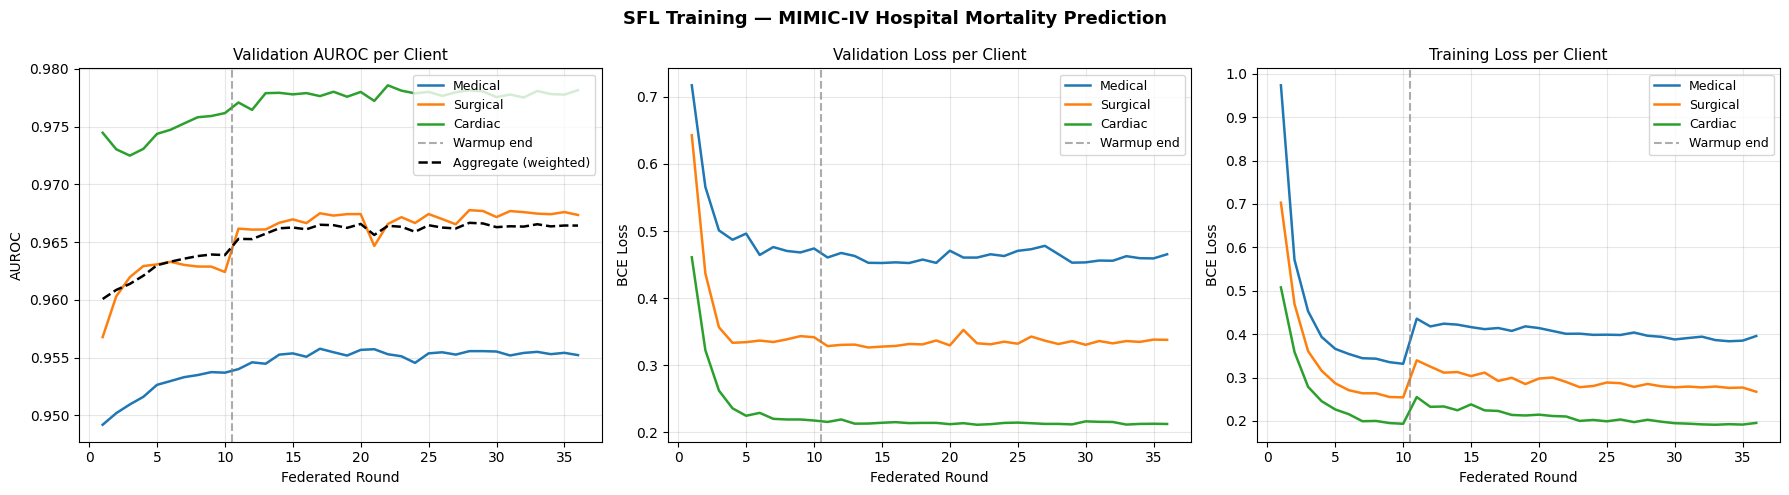

Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/training_curves.png


In [16]:
def plot_training_curves(history: dict) -> None:
    client_names = [info['name'].capitalize() for info in CLIENT_INFO]
    colors       = ['#1f77b4', '#ff7f0e', '#2ca02c']
    rounds       = history['round']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        'SFL Training — MIMIC-IV Hospital Mortality Prediction',
        fontsize=13, fontweight='bold',
    )

    panels = [
        ('val_auroc',  'AUROC',    'Validation AUROC per Client'),
        ('val_loss',   'BCE Loss', 'Validation Loss per Client'),
        ('train_loss', 'BCE Loss', 'Training Loss per Client'),
    ]

    for ax, (metric, ylabel, title) in zip(axes, panels):
        for cid, (name, color) in enumerate(zip(client_names, colors)):
            ax.plot(rounds, history[metric][cid],
                    label=name, color=color, lw=1.8)
        ax.axvline(
            x=WARMUP_ROUNDS + 0.5,
            color='gray', linestyle='--', alpha=0.65,
            label='Warmup end',
        )
        ax.set_xlabel('Federated Round', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    # Overlay weighted-aggregate AUROC on the first panel
    axes[0].plot(
        rounds, history['agg_auroc'],
        'k--', lw=1.8, label='Aggregate (weighted)',
    )
    axes[0].legend(fontsize=9)

    plt.tight_layout()
    fig_path = f'{RESULTS_DIR}/training_curves.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path}')


plot_training_curves(history)

## Final Per-Client Evaluation

In [17]:
print('\nFinal evaluation on validation sets (best checkpoint):\n')

final_metrics: list = []
val_sizes     = [len(vl.dataset) for vl in val_loaders]

for cid in range(NUM_CLIENTS):
    m = evaluate_client(
        encoders[cid], server_model,
        val_loaders[cid], criteria[cid],
    )
    final_metrics.append(m)

# Weighted aggregate metrics
total         = sum(val_sizes)
agg_auroc_fin = sum(m['auroc'] * s for m, s in zip(final_metrics, val_sizes)) / total
agg_auprc_fin = sum(m['auprc'] * s for m, s in zip(final_metrics, val_sizes)) / total
agg_f1_fin    = sum(m['f1']    * s for m, s in zip(final_metrics, val_sizes)) / total

# Print summary table
_hdr = f"{'Client':<12} {'AUROC':>7} {'AUPRC':>7} {'F1':>7} {'Sens':>7} {'Spec':>7} {'Prec':>7}"
print(_hdr)
print('-' * len(_hdr))
for info, m in zip(CLIENT_INFO, final_metrics):
    print(
        f"{info['name'].capitalize():<12} "
        f"{m['auroc']:>7.4f} {m['auprc']:>7.4f} "
        f"{m['f1']:>7.4f} {m['sensitivity']:>7.4f} "
        f"{m['specificity']:>7.4f} {m['precision']:>7.4f}"
    )
print('-' * len(_hdr))
print(
    f"{'Aggregate (w)':<12} "
    f"{agg_auroc_fin:>7.4f} {agg_auprc_fin:>7.4f} "
    f"{agg_f1_fin:>7.4f}"
)


Final evaluation on validation sets (best checkpoint):

Client         AUROC   AUPRC      F1    Sens    Spec    Prec
------------------------------------------------------------
Medical       0.9556  0.8572  0.7418  0.8395  0.9186  0.6644
Surgical      0.9678  0.8635  0.7452  0.8907  0.9350  0.6405
Cardiac       0.9781  0.8438  0.7169  0.8720  0.9583  0.6086
------------------------------------------------------------
Aggregate (w)  0.9667  0.8541  0.7338


## ROC & Precision-Recall Curves

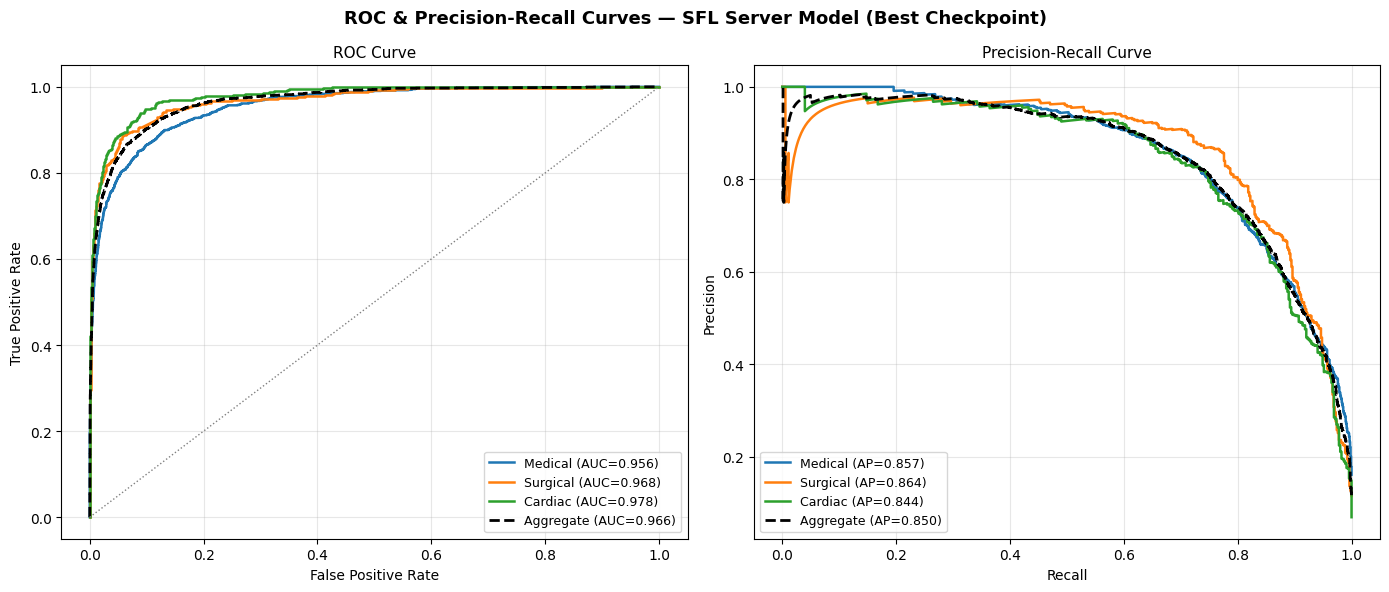

Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/roc_pr_curves.png


In [18]:
def plot_roc_pr_curves() -> None:
    client_names = [info['name'].capitalize() for info in CLIENT_INFO]
    colors       = ['#1f77b4', '#ff7f0e', '#2ca02c']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        'ROC & Precision-Recall Curves — SFL Server Model (Best Checkpoint)',
        fontsize=13, fontweight='bold',
    )

    all_labels_agg: list = []
    all_probs_agg:  list = []

    for cid, (name, color) in enumerate(zip(client_names, colors)):
        enc = encoders[cid]
        enc.eval()
        server_model.eval()

        all_logits, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loaders[cid]:
                logits = server_model(enc(X_batch.to(DEVICE))).cpu()
                all_logits.append(logits)
                all_labels.append(y_batch)

        logits_np = torch.cat(all_logits).numpy().ravel()
        labels_np = torch.cat(all_labels).numpy().ravel().astype(int)
        probs_np  = 1.0 / (1.0 + np.exp(-logits_np))

        fpr, tpr, _       = roc_curve(labels_np, probs_np)
        prec, rec, _      = precision_recall_curve(labels_np, probs_np)
        auc_val           = roc_auc_score(labels_np, probs_np)
        ap_val            = average_precision_score(labels_np, probs_np)

        axes[0].plot(fpr, tpr, color=color, lw=1.8, label=f'{name} (AUC={auc_val:.3f})')
        axes[1].plot(rec, prec, color=color, lw=1.8, label=f'{name} (AP={ap_val:.3f})')

        all_labels_agg.extend(labels_np)
        all_probs_agg.extend(probs_np)

    # Aggregate curves (all clients pooled)
    fpr_a, tpr_a, _  = roc_curve(all_labels_agg, all_probs_agg)
    prec_a, rec_a, _ = precision_recall_curve(all_labels_agg, all_probs_agg)
    auc_a  = roc_auc_score(all_labels_agg, all_probs_agg)
    ap_a   = average_precision_score(all_labels_agg, all_probs_agg)

    axes[0].plot(fpr_a, tpr_a, 'k--', lw=2, label=f'Aggregate (AUC={auc_a:.3f})')
    axes[1].plot(rec_a, prec_a, 'k--', lw=2, label=f'Aggregate (AP={ap_a:.3f})')

    axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
    axes[0].set_xlabel('False Positive Rate', fontsize=10)
    axes[0].set_ylabel('True Positive Rate', fontsize=10)
    axes[0].set_title('ROC Curve', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel('Recall', fontsize=10)
    axes[1].set_ylabel('Precision', fontsize=10)
    axes[1].set_title('Precision-Recall Curve', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fig_path = f'{RESULTS_DIR}/roc_pr_curves.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path}')


plot_roc_pr_curves()

## Save Outputs

In [19]:
# ── Model weights ─────────────────────────────────────────────────────────────
torch.save(
    server_model.state_dict(),
    f'{RESULTS_DIR}/server_model_best.pth',
)
print(f'Saved → {RESULTS_DIR}/server_model_best.pth')

for info in CLIENT_INFO:
    cid, name = info['id'], info['name']
    path = f'{RESULTS_DIR}/client{cid}_{name}_encoder_sfl.pth'
    torch.save(encoders[cid].state_dict(), path)
    print(f'Saved → {path}')

# ── Round-by-round training metrics CSV ──────────────────────────────────────
rows = []
for i, rnd in enumerate(history['round']):
    row = {
        'round':     rnd,
        'phase':     history['phase'][i],
        'agg_auroc': history['agg_auroc'][i],
    }
    for cid in range(NUM_CLIENTS):
        n = CLIENT_INFO[cid]['name']
        row[f'{n}_train_loss'] = history['train_loss'][cid][i]
        row[f'{n}_val_loss']   = history['val_loss'][cid][i]
        row[f'{n}_val_auroc']  = history['val_auroc'][cid][i]
        row[f'{n}_val_auprc']  = history['val_auprc'][cid][i]
    rows.append(row)

metrics_csv = f'{RESULTS_DIR}/training_metrics.csv'
pd.DataFrame(rows).to_csv(metrics_csv, index=False)
print(f'Saved → {metrics_csv}')

# ── Final evaluation JSON ─────────────────────────────────────────────────────
eval_summary = {
    'best_agg_auroc':  round(best_agg_auroc,   4),
    'final_agg_auroc': round(float(agg_auroc_fin), 4),
    'final_agg_auprc': round(float(agg_auprc_fin), 4),
    'final_agg_f1':    round(float(agg_f1_fin),    4),
    'training_config': {
        'num_rounds':          NUM_ROUNDS,
        'warmup_rounds':       WARMUP_ROUNDS,
        'batch_size':          BATCH_SIZE,
        'lr_server':           LR_SERVER,
        'lr_encoder':          LR_ENCODER,
        'weight_decay':        WEIGHT_DECAY,
        'early_stop_patience': EARLY_STOP_PATIENCE,
        'max_pos_weight':      MAX_POS_WEIGHT,
    },
    'clients': [
        {
            'id':          cid,
            'name':        CLIENT_INFO[cid]['name'],
            'val_size':    val_sizes[cid],
            'auroc':       round(float(m['auroc']),       4),
            'auprc':       round(float(m['auprc']),       4),
            'f1':          round(float(m['f1']),          4),
            'sensitivity': round(float(m['sensitivity']), 4),
            'specificity': round(float(m['specificity']), 4),
            'precision':   round(float(m['precision']),   4),
            'confusion_matrix': {
                'tn': m['tn'], 'fp': m['fp'],
                'fn': m['fn'], 'tp': m['tp'],
            },
        }
        for cid, m in enumerate(final_metrics)
    ],
}

eval_json = f'{RESULTS_DIR}/final_evaluation.json'
with open(eval_json, 'w') as fh:
    json.dump(eval_summary, fh, indent=2)
print(f'Saved → {eval_json}')

print('\nAll outputs saved successfully.')
print(f'Results directory: {RESULTS_DIR}')

Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/server_model_best.pth
Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/client0_medical_encoder_sfl.pth
Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/client1_surgical_encoder_sfl.pth
Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/client2_cardiac_encoder_sfl.pth
Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/training_metrics.csv
Saved → /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server/final_evaluation.json

All outputs saved successfully.
Results directory: /content/drive/MyDrive/Fockup Dataset MIMIC IV/MIMIC IV 3.1/results/server
